In [ ]:
import pandas as pd
import numpy as np

df=pd.DataFrame(np.random.randint(0,100,(10,3)))
df.head()
df.columns=['Sales','Units',"Transactions"]

In [ ]:
Customer_list=["Customer"+str(i) for i in range(1,11)]

In [ ]:
df.index=Customer_list

In [ ]:
df

,Sales,Units,Transactions
Customer1,45,87,46
Customer2,55,42,24
Customer3,55,89,82
Customer4,76,54,4
Customer5,94,58,70
Customer6,52,85,59
Customer7,55,86,50
Customer8,81,85,47
Customer9,85,46,55
Customer10,20,26,83


In [ ]:
### scikit learn
### stat models

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering

In [ ]:
km=KMeans(n_clusters=3)
km.fit(df)
km.labels_

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 2], dtype=int32)

In [ ]:
am=AgglomerativeClustering(n_clusters=3)
am.fit(df)
am.labels_

array([2, 0, 2, 0, 0, 2, 2, 2, 0, 1])

In [ ]:
import an ml  model
create an object
use object to call fit and predict methods/ labels_

In [ ]:
km=KMeans(n_clusters=3)
km.fit(df)
km.labels_

array([1, 2, 1, 2, 1, 1, 1, 1, 1, 0], dtype=int32)

In [ ]:
df['clusters']=km.labels_

In [ ]:
df

,Sales,Units,Transactions,clusters
Customer1,45,87,46,1
Customer2,55,42,24,2
Customer3,55,89,82,1
Customer4,76,54,4,2
Customer5,94,58,70,1
Customer6,52,85,59,1
Customer7,55,86,50,1
Customer8,81,85,47,1
Customer9,85,46,55,1
Customer10,20,26,83,0


In [ ]:
df.groupby("clusters").mean()

,Sales,Units,Transactions
clusters,,,
0,20.000000,26.000000,83.000000
1,66.714286,76.571429,58.428571
2,65.500000,48.000000,14.000000


In [ ]:
cluster 1: High value customers

  retain and reward
cluster 2: hig frequency low value customers
  increase basket value and order value
cluster 0 = Moderate frequence low value customers
  upsell and improve engagement

In [ ]:
### walmart
  ### sep 1: 3 clusters  ( back to school)
  ### Marketing Team (customer email id, phone number)
  ### B1G1 (BOGO Offers)
  ### Sep 2- Sep 10th
  ### sep 10th

In [ ]:
### customer segmentation
### employee segmentation
### image segmentaiton
### store level segmentation
### product level segmentaiton
### domains, retail,pharma,airlines,banking

In [ ]:
df_without_cluster=df.drop("clusters",axis=1)

In [ ]:
df_without_cluster

,Sales,Units,Transactions
Customer1,45,87,46
Customer2,55,42,24
Customer3,55,89,82
Customer4,76,54,4
Customer5,94,58,70
Customer6,52,85,59
Customer7,55,86,50
Customer8,81,85,47
Customer9,85,46,55
Customer10,20,26,83


In [ ]:
X=df[['Sales',"Units",'Transactions']]

In [ ]:
from scipy.cluster.hierarchy import linkage,dendrogram
Z=linkage(X,method='single',metric='euclidean')

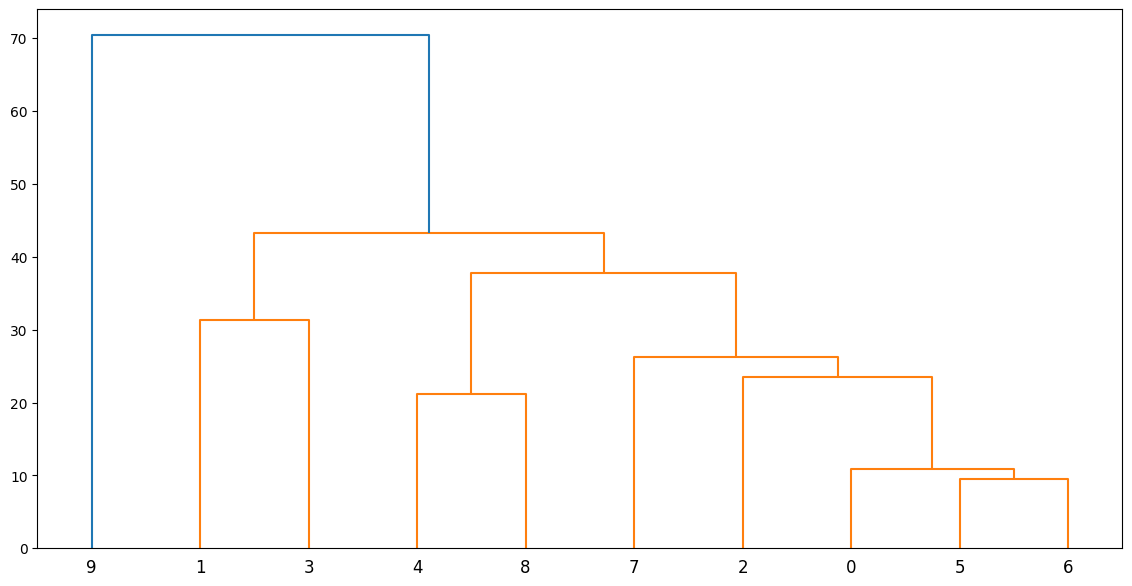

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))
dendrogram(Z)
plt.show()

In [ ]:
am=AgglomerativeClustering(n_clusters=3)
am.fit(df)
am.labels_

array([2, 0, 2, 0, 0, 2, 2, 2, 0, 1])

In [ ]:
import seaborn as sns
df=sns.load_dataset("titanic")
df_subset=df[['age','fare']]
df_subset.shape

(891, 2)

In [ ]:
df_subset.fillna(df['age'].median(),inplace=True)

/tmp/ipykernel_1593/207090939.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.fillna(df['age'].median(),inplace=True)


In [ ]:
df_subset.isna().sum()

,0
age,0
fare,0


In [ ]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3)
km.fit(df_subset)
len(km.labels_)

891

In [ ]:
df_subset['clusters']=km.labels_

/tmp/ipykernel_1593/757302240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['clusters']=km.labels_


In [ ]:
df_subset['clusters'].value_counts(normalize=True)*100

,proportion
clusters,
0,87.205387
1,12.457912
2,0.336700


clusters             0           1           2
age  count  777.000000  111.000000    3.000000
     mean    28.740347   33.548829   35.333333
     std     12.767940   14.144929    0.577350
     min      0.420000    0.920000   35.000000
     25%     22.000000   24.000000   35.000000
     50%     28.000000   30.000000   35.000000
     75%     34.000000   42.500000   35.500000
     max     80.000000   70.000000   36.000000
fare count  777.000000  111.000000    3.000000
     mean    17.947645  119.023796  512.329200
     std     13.784253   57.539815    0.000000
     min      0.000000   69.300000  512.329200
     25%      7.895800   78.266700  512.329200
     50%     13.000000   90.000000  512.329200
     75%     26.000000  141.077050  512.329200
     max     66.600000  263.000000  512.329200

In [ ]:
df_subset.groupby("clusters")['fare'].describe().T

clusters,0,1,2
count,777.000000,111.000000,3.0000
mean,17.947645,119.023796,512.3292
std,13.784253,57.539815,0.0000
min,0.000000,69.300000,512.3292
25%,7.895800,78.266700,512.3292
50%,13.000000,90.000000,512.3292
75%,26.000000,141.077050,512.3292
max,66.600000,263.000000,512.3292


1. **Cluster 0 – Low-Fare Majority:** Contains **777 passengers (87.2%)**, with an average fare of **17.95**. This is the dominant economy/low-fare segment.

2. **Cluster 1 – Premium Segment:** Contains **111 passengers (12.5%)**, with an average fare of **119.02**, around **6.6× higher** than Cluster 0.

3. **Cluster 2 – Extreme High-Fare Group:** Contains only **3 passengers (0.3%)**, all paying exactly **512.33**, indicating a very small extreme/outlier group.

4. **Clear Fare Separation:** The clusters show strong separation: **17.95 → 119.02 → 512.33**, suggesting Fare is a major factor driving the clustering.

5. **Cluster 2 Needs Investigation:** Since it has only **3 observations and zero standard deviation**, these records should be examined separately rather than immediately treating them as a meaningful customer segment.